# Detekcja krawędzi

## Cel ćwiczenia

- Zapoznanie z metodami detekcji krawędzi:
    - Sobel, Prewitt, Roberts - przypomnienie,
    - Laplasjan z Gaussa (LoG – ang. Laplacian of Gaussian),
    - Canny.

Detekcja krawędzi przez wiele lat była podstawą algorytmów segmentacji.
Krawędzie wykrywane są najczęściej z wykorzystaniem pierwszej (gradient) i drugiej (Laplasjan) pochodnej przestrzennej.
Wykorzystanie obu metod zaprezentowane zostało w ćwiczeniu *Przetwarzanie wstępne. Filtracja kontekstowa*.

W niniejszym ćwiczeniu poznane detektory krawędzi zostaną porównane z bardziej zaawansowanymi: Laplasjan z funkcji Gaussa (LoG), Zero Crossing i Canny.

## Laplasjan z Gaussa (LoG)

Funkcja Gaussa:<br>
\begin{equation}
h(r) = e^{\frac{-r^2}{2 \sigma^2}}
\end{equation}<br>
gdzie:
- $r^2 = x^2 + y^2$
- $\sigma$ to odchylenie standardowe.

Działanie filtracji Gaussowskiej zostało przedstawione w ćwiczeniu "Przetwarzanie wstępne". W jej wyniku następuje rozmazanie obrazu.
Laplasjan tej funkcji dany jest wzorem:

\begin{equation}
\nabla^2 h(r) = \frac{r^2 - 2\sigma^2}{\sigma^4} e^{-\frac{r^2}{2\sigma^2}}
\end{equation}

Funkcję (z oczywistych powodów) nazywamy Laplasjan z Gaussa (LoG).
Ponieważ druga pochodna jest operacją liniową, konwolucja obrazu z $\nabla^2 h(r)$ daje taki sam efekt jak zastosowanie filtracji Gaussa na obrazie, a następnie obliczenie Laplasjanu z wyniku.
Lokalizacja krawędzi polega na znalezieniu miejsca, gdzie po filtracji LoG następuje zmiana znaku.

1. Wczytaj obraz *house.png*.
2. Wykonaj rozmycie Gaussowskie obrazu wejściowego.
W tym celu wykorzysaj funkcję `cv2.GaussianBlur(img, kSize, sigma)`.
Pierwszy argument jest obrazem wejśćiowym.
Drugi jest rozmiarem filtru (podanym w nawiasach okrągłych, np. *(3, 3)*).
Trzecim argumentem jest odchylenie standardowe. Wartość jest dobrana automatycznie, jeśli zosanie podana wartość `0` (będą równe rozmiarowi).
3. Oblicz laplasjan obrazu rozmytego.
W tym celu wykorzysaj funkcję `cv2.Laplacian(img, ddepth)`.
Pierszym argumentem jest obraz wejściowy.
Drugim argumentem jest typ danych wejściowych. Użyj `cv2.CV_32F`.
4. Wyznacz miejsca zmiany znaku.
Zaimplementuj funkcję `crossing(LoG, thr)`:
    - Najpierw stwórz tablicę, do której zostanie zapisany wynik.
    Jej rozmiar jest taki sam jak przetwarzanego obrazu.
    - Następnie wykonaj pętle po obrazie (bez ramki jednopikselowej).
    W każdej iteracji stwórz otoczenie o rozmiarze $3 \times 3$.
    Dla otoczenia oblicz wartość maksymalną i minimalną.
    - Jeśli wartości te mają przeciwne znaki, to do danego miejsca tablicy przypisz wartość:
        - jeśli piksel wejściowy > 0, to dodaj do niego wartość bezwzględną minimum.
        - jeśli piksel wejściowy < 0, to do jego wartości bezwzględnej dodaj maksimum.
    - Zmień zakres wykonanej tablicy do $<0, 255>$.
    - Wykonaj progowanie tablicy. Próg jest argumentem wejściowym.
    - Przeskaluj dane binarne do wartości `[0, 255]`.
    - Wykonaj konwersję do typu *uint8*.
    - Wykonaj rozmycie medianowe wyniku.
    Wykorzystaj funkcję `cv2.medianBlur(img, kSize)`.
    Pierwszym argumentem jest obraz wejśćiowy, a drugim rozmiar filtra.
    - Zwróć wyznaczoną tablicę.
5. Wyświetl obraz wynikowy.
6. Dobierz parametry (rozmiar filtru Gaussa, odchylenie standardowe, próg binaryzacji) tak, by widoczne były kontury domu, ale nie dachówki.

In [83]:
def two_plot(img1,img2):
  fig,ax=plt.subplots(1,2, figsize=(10,5))
  ax[0].imshow(img1)
  ax[1].imshow(img2)

def three_plot(img1,img2,img3):
  fig,ax=plt.subplots(1,3, figsize=(15,5))
  ax[0].imshow(img1)
  ax[1].imshow(img2)
  ax[2].imshow(img3)


<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

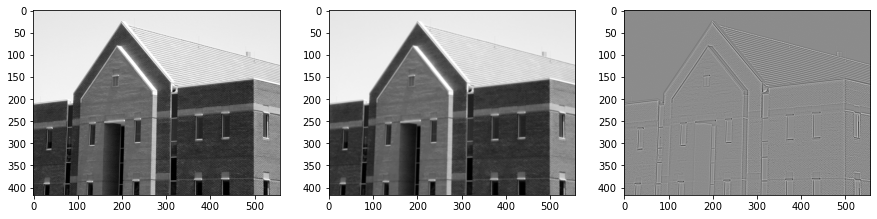

In [84]:
import cv2
from matplotlib import pyplot as plt
import numpy as np
import math
import os

if not os.path.exists("dom.png") :
    !wget https://raw.githubusercontent.com/vision-agh/poc_sw/master/09_Canny/dom.png --no-check-certificate

plt.gray()

d=cv2.imread('dom.png',cv2.IMREAD_GRAYSCALE)
dg=cv2.GaussianBlur(d,(3, 3),0)
dgg=cv2.Laplacian(dg, cv2.CV_32F)
plt.figure()
three_plot(d,dg,dgg)

In [85]:
def crossing(img, thr):
    
    canvas=np.zeros((len(img),len(img[0])))
    for i in range(1,len(img)-1):
        for j in range(1,len(img[0])-1):
            mask=img[i-1:i+2,j-1:j+2]
            maxx=mask.max()
            minn=mask.min()
            if(minn*maxx<0):
                if(img[i,j]>0):
                    canvas[i,j]=img[i,j]+np.abs(minn)
                if(img[i,j]<0):
                    canvas[i,j]=np.abs(img[i,j])+maxx
                    
    normcanvas=cv2.normalize(canvas,None,0,255,cv2.NORM_MINMAX)
    newcanvas=np.where(normcanvas<thr,0,1)
    newcanvas*=255
    newcanvas=newcanvas.astype('uint8')
    newcanvas=cv2.medianBlur(newcanvas,3)
    return newcanvas

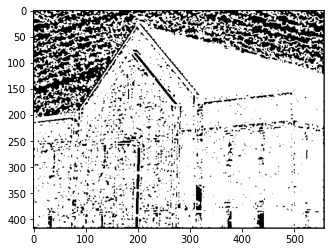

In [86]:
d2=cv2.GaussianBlur(d,(9, 9),1,5)
dg2=cv2.Laplacian(d2,cv2.CV_32F)
I_dom_cross=crossing(dg2,5)
plt.imshow(I_dom_cross,vmin=0,vmax=256)

## Algorytm Canny'ego

> Algorytm Canny'ego to często wykorzystywana metoda detekcji krawędzi.
> Zaproponowana została w~1986r. przez Johna F. Cannego.
> Przy jego projektowaniu założono trzy cele:
> - niska liczba błędów - algorytm powinien znajdywać wszystkie krawędzie oraz generować jak najmniej fałszywych detekcji,
> - punkty krawędziowe powinny być poprawnie lokalizowane - wykryte punkty powinny być jak najbardziej zbliżone do rzeczywistych,
> - krawędzie o szerokości 1 piksela - algorytm powinien zwrócić jeden punkt dla każdej rzeczywistej krawędzi.

Zaimplementuj pierwszą część algorytmu detekcji krawędzi Canny'ego:
1. W pierwszym kroku obraz przefiltruj dwuwymiarowym filtrem Gaussa.
2. Następnie oblicz gradient pionowy i poziomy ($g_x $ i $g_y$).
Jedną z metod jest filtracja Sobela.
3. Dalej oblicz amplitudę:
$M(x,y)  = \sqrt{g_x^2+g_y^2}$ oraz kąt:
$\alpha(x,y) = arctan(\frac{g_y}{g_x})$.
Do obliczenia kąta wykorzystaj funkcję `np.arctan2(x1, x2)`.
Wynik jest w radianach.
4. W kolejnym etapie wykonaj kwantyzację kątów gradientu.
Kąty od $-180^\circ$ do $180^\circ$ można podzielić na 8 przedziałów:
[$-22.5^\circ, 22.5^\circ$], [$22.5^\circ, 67.5^\circ$],
[$67.5^\circ, 112.5^\circ$], [$112.5^\circ, 157.5^\circ$],
[$157.5^\circ, -157.5^\circ$], [$-157.5^\circ, -112.5^\circ$],
[$-112.5^\circ, -67.5^\circ$], [$-67.5^\circ, -22.5^\circ$].
Przy czym należy rozpatrywać tylko 4 kierunki:
    - pionowy ($d_1$),
    - poziomy ($d_2$),
    - skośny lewy ($d_3$),
    - skośny prawy ($d_4$).
5. Dalej przeprowadź eliminację pikseli, które nie mają wartości maksymalnej (ang. *nonmaximal suppresion*).
Celem tej operacji jest redukcja szerokości krawędzi do rozmiaru 1 piksela.
Algorytm przebiega następująco.
W rozpatrywanym otoczeniu o rozmiarze $3 \times 3$:
    - określ do którego przedziału należy kierunek gradientu piksela centralnego ($d_1, d_2, d_3, d_4$).
    - przeanalizuje sąsiadów leżących na tym kierunku.
Jeśli choć jeden z nich ma amplitudę większą niż piksel centralny, to należy uznać, że nie jest lokalnym maksimum i do wyniku przypisać $g_N(x,y) = 0$.
W przeciwnym przypadku $g_N(x,y) = M(x,y)$.
Przez $g_N$ rozumiemy obraz detekcji lokalnych maksimów.
Zaimplementuj funkcję `nonmax`.
Pierwszym argementem jest macierz kierunków (po kwantyzacji).
Drugim argumentem jest macierz amplitudy.
6. Ostatnią operacją jest binaryzacja obrazu $g_N$.
Stosuje się tutaj tzw. binaryzację z histerezą.
Wykorzystuje się w niej dwa progi: $T_L$ i $T_H$, przy czym $T_L < T_H$.
Canny zaproponował, aby stosunek progu wyższego do niższego był jak 3 lub 2 do 1.
Rezultaty binaryzacji można opisać jako:<br>
$g_{NH}(x,y) = g_N(x,y) \geq TH $<br>
$g_{NL}(x,y) = TH > g_N(x,y) \geq TL $<br>
Można powiedzieć, że na obrazie $g_{NH}$ są "pewne" krawędzie.
Natomiast na $g_{NL}$ "potencjalne".
7. Na jednym obrazie zaznacz piksele należące do obrazu $g_{NH}$ jako czerwone oraz należące do obrazu $g_{NL}$ jako niebieskie.
Wyświetl obraz.

In [87]:
def nonmax(direc,A):
    x,y=direc.shape
    gn=np.zeros((x,y))
    for i in range(1,x-1):
        for j in range(1,y-1):
            if(direc[i,j]==1):
                if(A[i,j-1]>A[i,j] or A[i,j+1]>A[i,j]):
                    gn[i,j]=0
                else:
                    gn[i,j]=A[i,j]
            elif(direc[i,j]==2):
                if(A[i+1,j-1]>A[i,j] or A[i-1,j+1]>A[i,j]):
                    gn[i,j]=0
                else:
                    gn[i,j]=A[i,j]
            elif(direc[i,j]==3):
                if(A[i+1,j]>A[i,j] or A[i-1,j]>A[i,j]):
                    gn[i,j]=0
                else:
                    gn[i,j]=A[i,j]
            elif(direc[i,j]==4):
                if(A[i-1,j-1]>A[i,j] or A[i+1,j+1]>A[i,j]):
                    gn[i,j]=0
                else:
                    gn[i,j]=A[i,j]
    return gn

In [88]:
def canny(img,th,tl):
    x,y=img.shape
    imgg=cv2.GaussianBlur(img,(5, 5),0)
    sx=np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
    sy=np.array([[-1,-2,-1],[0,0,0],[1,2,1]])
    gx=cv2.filter2D(imgg,-1,sx)
    gy=cv2.filter2D(imgg,-1,sy)
    A=np.sqrt(gx**2+gy**2)
    kat=np.arctan2(gy, gx)
    kat=kat*180./np.pi
    kat[kat<0]+=180
    direc=np.zeros((x,y))
    
    for i in range (x):
        for j in range (y):
            if 0<=kat[i,j]<22.5:
                direc[i,j]=1
            elif 22.5<=kat[i,j]<67.5:
                direc[i,j]=2
            elif 67.5<=kat[i,j]<112.5:
                direc[i,j]=3
            elif 112.5<=kat[i,j]<157.5:
                direc[i,j]=4
            elif 157.5<=kat[i,j]<=180:
                direc[i,j]=1
    
    gn = nonmax(direc,A)
    gnh=np.where(gn>=th,1,0)
    gnl=np.where(np.logical_and(th>gn,gn>=tl),1,0)
    return gnh,gnl

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Text(0.5, 1.0, 'obraz')

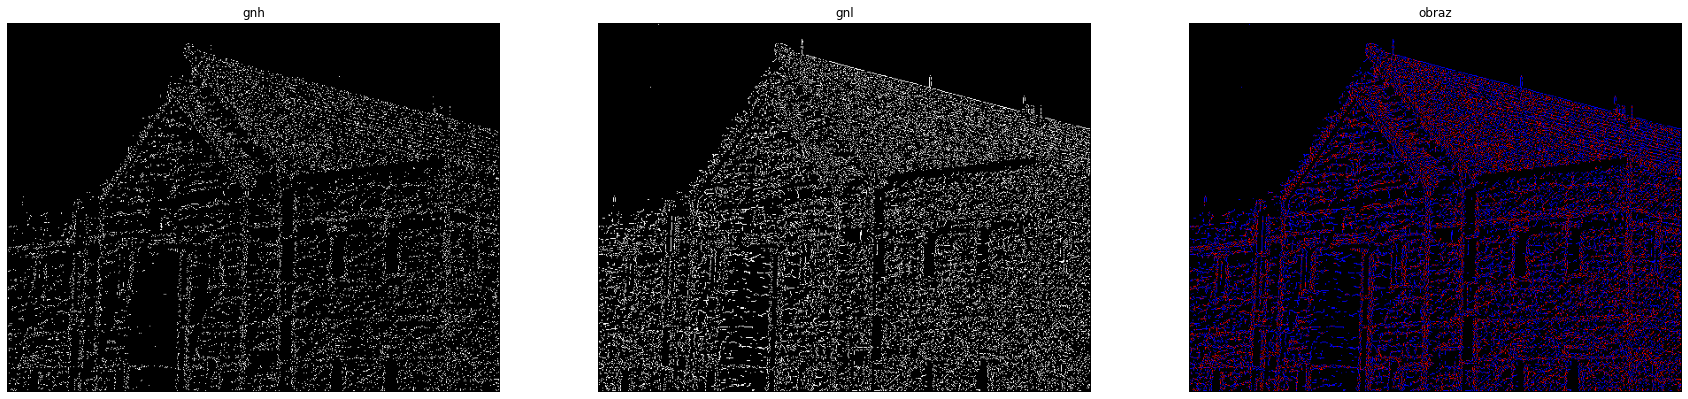

In [92]:
gnh,gnl=canny(d,14,7)

x,y=gnh.shape
blue_red=np.zeros((x,y,3))
for i in range(0,x):
    for j in range(0,y):
        if(gnh[i,j]==1):
            blue_red[i,j]=[255,0,0]
        elif(gnl[i,j]==1):
            blue_red[i,j]=[0,0,255]

f, (ax1,ax2,ax3)=plt.subplots(1,3,figsize=(30,10))
ax1.imshow(gnh)
ax2.imshow(gnl)
ax3.imshow(blue_red)
ax1.axis('off')
ax2.axis('off')
ax3.axis('off')
ax1.set_title('gnh')
ax2.set_title('gnl')
ax3.set_title('obraz')

## Algorytm Canny'ego - OpenCV

1. Wykonaj dektekcję krawędzi metodą Canny'ego wykorzystując funkcję `cv2.Canny`.
    - Pierwszym argumentem funkcji jest obraz wejściowy.
    - Drugim argumentem jest mniejszy próg.
    - Trzecim argumentem jest większy próg.
    - Czwarty argument to tablica, do której wpisany zostanie wynik.
    Można zwrócić go przez wartość i podać wartość `None`.
    - Piąty argument to rozmiar operatora Sobela (w naszym przypadku 3).
    - Szósty argument to rodzaj używanej normy.
    0 oznacza normę $L_1$, 1 oznacza normę $L_2$. Użyj $L_2$.
2. Wynik wyświetl i porównaj z wykonaną częściową implementacją w poprzednim ćwiczeniu.
Na czym polegają różnice?

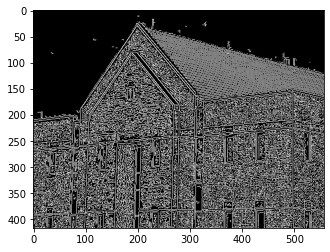

In [90]:
dcan=cv2.Canny(d,7,14,None,3,1)
plt.imshow(dcan)

Obraz jest o wiele wyraźniejszy